In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
dataset_path = "HistoricalQuotes.csv"

df = pd.read_csv(dataset_path)

print("\n")
print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Dataset Shape :", df.shape)



DATASET LOADED SUCCESSFULLY
Dataset Shape : (2518, 6)


In [3]:
print("\n")
print("=" * 70)
print("FIRST 5 RECORDS")
print("=" * 70)

display(df.head())



FIRST 5 RECORDS


,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [4]:
df.columns = df.columns.str.strip()

print("\n")
print("=" * 70)
print("COLUMN NAMES")
print("=" * 70)

print(df.columns.tolist())



COLUMN NAMES
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']


In [5]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("\n")
print("=" * 70)
print("DATE CONVERSION")
print("=" * 70)

print("Date Data Type :", df["Date"].dtype)



DATE CONVERSION
Date Data Type : datetime64[us]


In [6]:
price_columns = [
    "Close/Last",
    "Open",
    "High",
    "Low"
]

for column in price_columns:

    df[column] = (
        df[column]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
    )

In [7]:
df["Volume"] = (
    df["Volume"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)


In [8]:
print("\n")
print("=" * 70)
print("CLEANED DATA")
print("=" * 70)

display(df.head())



CLEANED DATA


,Date,Close/Last,Volume,Open,High,Low
0,2020-02-28,273.36,106721200.0,257.26,278.41,256.37
1,2020-02-27,273.52,80151380.0,281.10,286.00,272.96
2,2020-02-26,292.65,49678430.0,286.53,297.88,286.50
3,2020-02-25,288.08,57668360.0,300.95,302.53,286.13
4,2020-02-24,298.18,55548830.0,297.26,304.18,289.23


In [9]:
print("\n")
print("=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)



DATA TYPES
Date          datetime64[us]
Close/Last           float64
Volume               float64
Open                 float64
High                 float64
Low                  float64
dtype: object


In [10]:
print("\n")
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2518 non-null   datetime64[us]
 1   Close/Last  2518 non-null   float64       
 2   Volume      2518 non-null   float64       
 3   Open        2518 non-null   float64       
 4   High        2518 non-null   float64       
 5   Low         2518 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 118.2 KB


In [11]:
missing_values = df.isnull().sum()

print("\n")
print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

display(missing_values)



MISSING VALUES


Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
dtype: int64

In [12]:
duplicate_count = df.duplicated().sum()

print("\n")
print("=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)

print("Number of Duplicate Rows :", duplicate_count)



DUPLICATE RECORDS
Number of Duplicate Rows : 0


In [13]:
print("\n")
print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(df.describe())




STATISTICAL SUMMARY


,Date,Close/Last,Volume,Open,High,Low
count,2518,2518.000000,2.518000e+03,2518.000000,2518.000000,2518.000000
mean,2015-02-26 15:01:17.204130,114.769522,7.258009e+07,114.728443,115.766415,113.690582
min,2010-03-01 00:00:00,29.835700,1.136205e+07,29.392800,29.928600,28.464300
25%,2012-08-24 18:00:00,66.822475,3.053026e+07,66.877150,67.475300,66.372950
50%,2015-02-28 12:00:00,101.090000,5.295469e+07,101.115000,102.085000,100.350000
75%,2017-08-27 06:00:00,154.630000,9.861006e+07,154.610000,155.735000,153.325000
max,2020-02-28 00:00:00,327.200000,4.624423e+08,324.740000,327.850000,323.350000
std,NaN,60.662405,5.663113e+07,60.546893,61.134456,60.085105


In [14]:
df = df.sort_values(
    "Date"
).reset_index(
    drop=True
)

print("\n")
print("=" * 70)
print("CHRONOLOGICAL ORDER")
print("=" * 70)

print("Oldest Record:")
display(df.head(3))

print("Latest Record:")
display(df.tail(3))




CHRONOLOGICAL ORDER
Oldest Record:


,Date,Close/Last,Volume,Open,High,Low
0,2010-03-01,29.8557,137312041.0,29.3928,29.9286,29.3500
1,2010-03-02,29.8357,141486282.0,29.9900,30.1186,29.6771
2,2010-03-03,29.9043,92846488.0,29.8486,29.9814,29.7057


Latest Record:


,Date,Close/Last,Volume,Open,High,Low
2515,2020-02-26,292.65,49678430.0,286.53,297.88,286.50
2516,2020-02-27,273.52,80151380.0,281.10,286.00,272.96
2517,2020-02-28,273.36,106721200.0,257.26,278.41,256.37


In [15]:
print("\n")
print("=" * 70)
print("DATE RANGE")
print("=" * 70)

print(
    "Start Date :",
    df["Date"].min()
)

print(
    "End Date   :",
    df["Date"].max()
)



DATE RANGE
Start Date : 2010-03-01 00:00:00
End Date   : 2020-02-28 00:00:00


In [16]:
print("\n")
print("=" * 70)
print("CLOSING PRICE STATISTICS")
print("=" * 70)

print(
    "Minimum Closing Price :",
    round(df["Close/Last"].min(), 2)
)

print(
    "Maximum Closing Price :",
    round(df["Close/Last"].max(), 2)
)

print(
    "Average Closing Price :",
    round(df["Close/Last"].mean(), 2)
)

print(
    "Median Closing Price  :",
    round(df["Close/Last"].median(), 2)
)




CLOSING PRICE STATISTICS
Minimum Closing Price : 29.84
Maximum Closing Price : 327.2
Average Closing Price : 114.77
Median Closing Price  : 101.09


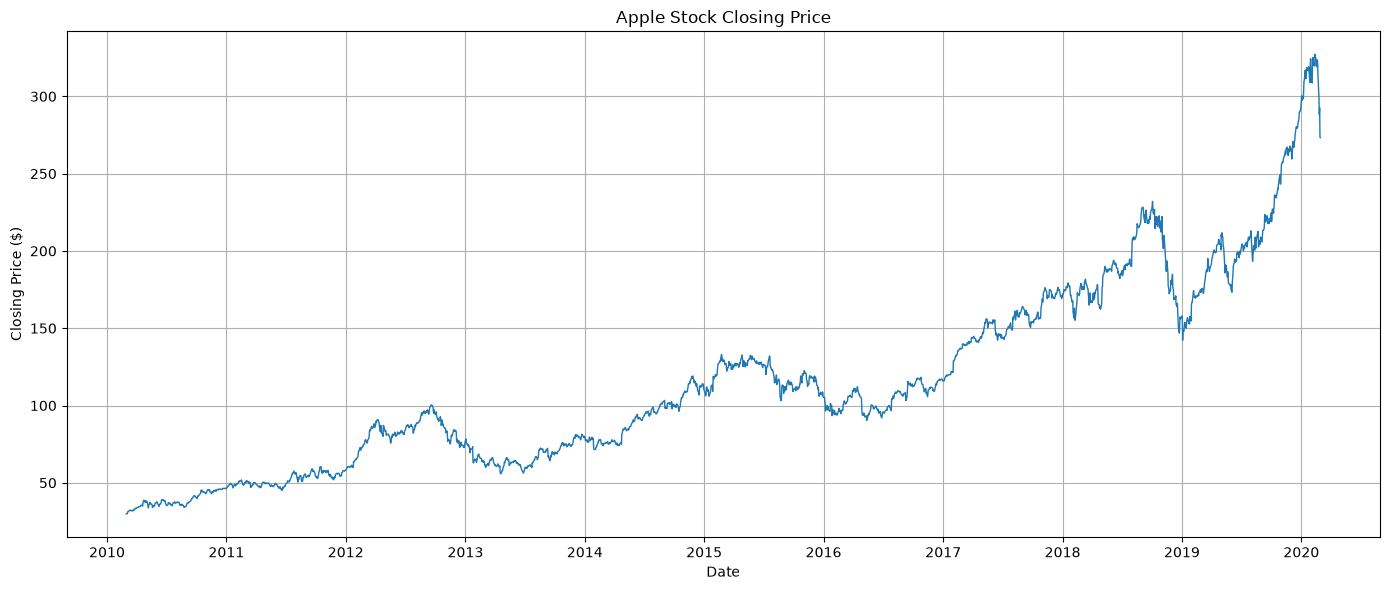

In [17]:
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    df["Date"],
    df["Close/Last"],
    linewidth=1
)

plt.title(
    "Apple Stock Closing Price"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Closing Price ($)"
)

plt.grid()

plt.tight_layout()

plt.show()


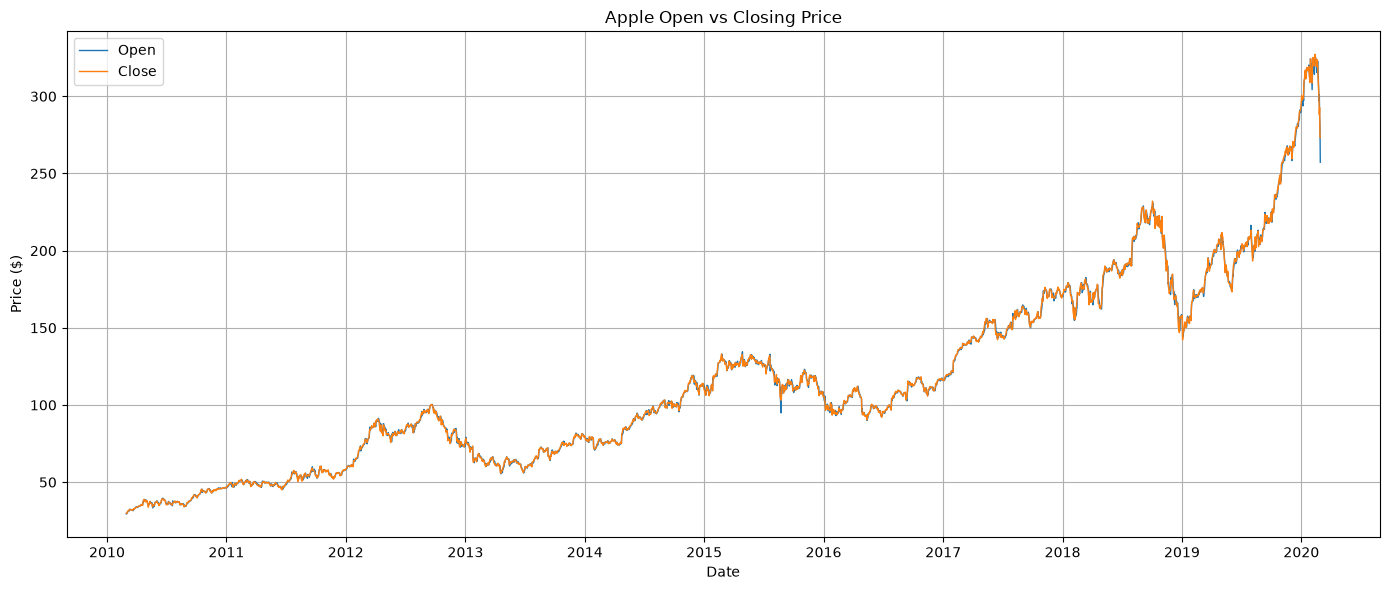

In [18]:
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    df["Date"],
    df["Open"],
    label="Open",
    linewidth=1
)

plt.plot(
    df["Date"],
    df["Close/Last"],
    label="Close",
    linewidth=1
)

plt.title(
    "Apple Open vs Closing Price"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Price ($)"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


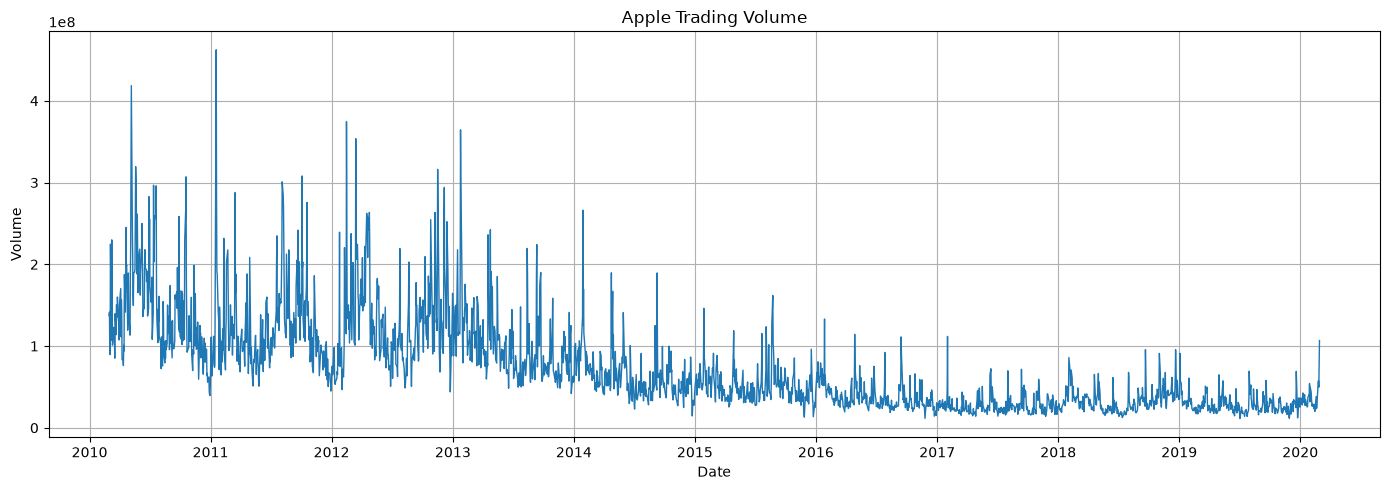

In [19]:
plt.figure(
    figsize=(14, 5)
)

plt.plot(
    df["Date"],
    df["Volume"],
    linewidth=1
)

plt.title(
    "Apple Trading Volume"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Volume"
)

plt.grid()

plt.tight_layout()

plt.show()


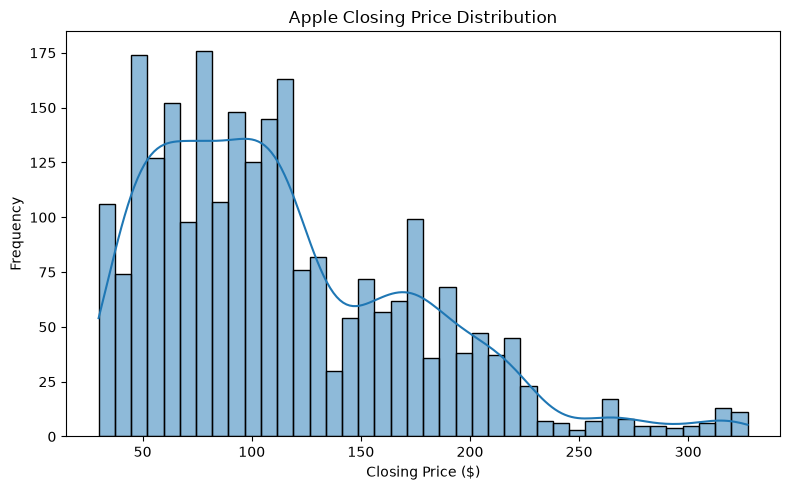

In [20]:
plt.figure(
    figsize=(8, 5)
)

sns.histplot(
    df["Close/Last"],
    bins=40,
    kde=True
)

plt.title(
    "Apple Closing Price Distribution"
)

plt.xlabel(
    "Closing Price ($)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()


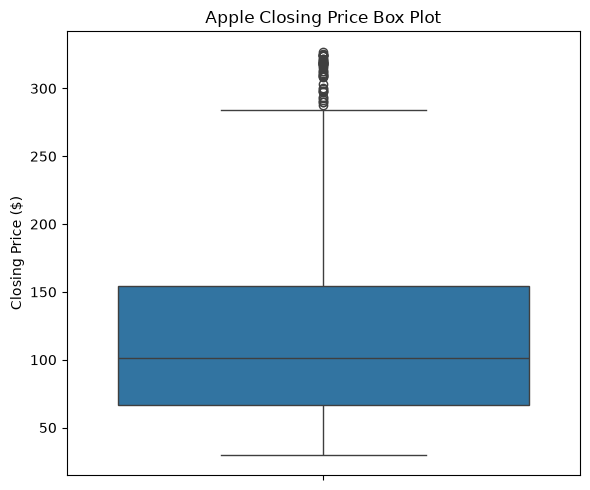

In [21]:
plt.figure(
    figsize=(6, 5)
)

sns.boxplot(
    y=df["Close/Last"]
)

plt.title(
    "Apple Closing Price Box Plot"
)

plt.ylabel(
    "Closing Price ($)"
)

plt.tight_layout()

plt.show()

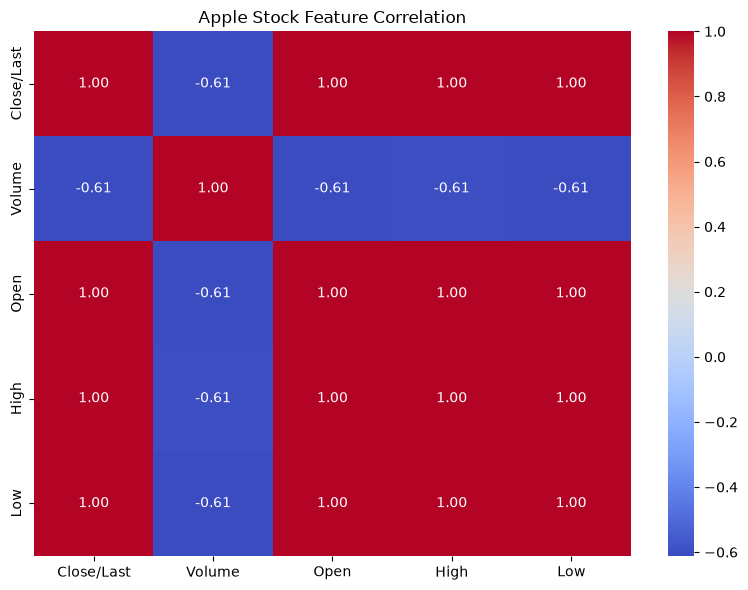

In [22]:

numeric_columns = [
    "Close/Last",
    "Volume",
    "Open",
    "High",
    "Low"
]

correlation_matrix = df[
    numeric_columns
].corr()

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Apple Stock Feature Correlation"
)

plt.tight_layout()

plt.show()


In [23]:
print("\n")
print("=" * 70)
print("INVALID VALUE CHECK")
print("=" * 70)

print(
    "Negative Closing Prices :",
    (df["Close/Last"] < 0).sum()
)

print(
    "Negative Volume         :",
    (df["Volume"] < 0).sum()
)



INVALID VALUE CHECK
Negative Closing Prices : 0
Negative Volume         : 0


In [24]:
summary = pd.DataFrame({

    "Parameter": [

        "Dataset",
        "Problem Type",
        "Total Records",
        "Total Features",
        "Target Variable",
        "Model",
        "Sequence Length",
        "Training Approach"
    ],

    "Value": [

        "Apple Historical Quotes",
        "Time Series Forecasting",
        len(df),
        len(df.columns),
        "Close/Last",
        "LSTM",
        30,
        "Chronological Split"
    ]

})

print("\n")
print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

display(summary)





FINAL DATASET SUMMARY


,Parameter,Value
0,Dataset,Apple Historical Quotes
1,Problem Type,Time Series Forecasting
2,Total Records,2518
3,Total Features,6
4,Target Variable,Close/Last
5,Model,LSTM
6,Sequence Length,30
7,Training Approach,Chronological Split


In [25]:
print("\n")
print("=" * 70)
print("FINAL DATASET CHECK")
print("=" * 70)

print(
    "Rows              :",
    len(df)
)

print(
    "Columns           :",
    len(df.columns)
)

print(
    "Missing Values    :",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows    :",
    df.duplicated().sum()
)

print(
    "Start Date        :",
    df["Date"].min()
)

print(
    "End Date          :",
    df["Date"].max()
)

print(
    "Minimum Close     :",
    round(df["Close/Last"].min(), 2)
)

print(
    "Maximum Close     :",
    round(df["Close/Last"].max(), 2)
)

print(
    "Average Close     :",
    round(df["Close/Last"].mean(), 2)
)





FINAL DATASET CHECK
Rows              : 2518
Columns           : 6
Missing Values    : 0
Duplicate Rows    : 0
Start Date        : 2010-03-01 00:00:00
End Date          : 2020-02-28 00:00:00
Minimum Close     : 29.84
Maximum Close     : 327.2
Average Close     : 114.77


In [26]:
print("Dataset           : Apple Historical Quotes")
print("Target            : Close/Last")
print("Model             : LSTM")
print("Sequence Length   : 30")
print("CPU Optimization  : Enabled")

print("=" * 70)

Dataset           : Apple Historical Quotes
Target            : Close/Last
Model             : LSTM
Sequence Length   : 30
CPU Optimization  : Enabled


In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler

In [28]:
SEQUENCE_LENGTH = 30

TRAIN_RATIO = 0.80

BATCH_SIZE = 16


print("\n")
print("=" * 70)
print("LSTM PREPROCESSING CONFIGURATION")
print("=" * 70)

print("Sequence Length :", SEQUENCE_LENGTH)
print("Train Ratio     :", TRAIN_RATIO)
print("Batch Size      :", BATCH_SIZE)
print("Data Type       : float32")
print("CPU Optimization: Enabled")



LSTM PREPROCESSING CONFIGURATION
Sequence Length : 30
Train Ratio     : 0.8
Batch Size      : 16
Data Type       : float32
CPU Optimization: Enabled


In [29]:
required_columns = [
    "Date",
    "Close/Last"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if len(missing_columns) > 0:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


In [30]:
stock_df = df[
    [
        "Date",
        "Close/Last"
    ]
].copy()

In [31]:
stock_df = stock_df.dropna(
    subset=[
        "Date",
        "Close/Last"
    ]
)

In [32]:
stock_df = stock_df.sort_values(
    "Date"
).reset_index(
    drop=True
)


print("\n")
print("=" * 70)
print("CLEAN DATASET")
print("=" * 70)

print(
    "Total Records :",
    len(stock_df)
)

print(
    "Start Date    :",
    stock_df["Date"].min()
)

print(
    "End Date      :",
    stock_df["Date"].max()
)




CLEAN DATASET
Total Records : 2518
Start Date    : 2010-03-01 00:00:00
End Date      : 2020-02-28 00:00:00


In [33]:
close_prices = stock_df[
    "Close/Last"
].values.astype(
    np.float32
)

close_prices = close_prices.reshape(
    -1,
    1
)


In [34]:
split_index = int(
    len(close_prices) * TRAIN_RATIO
)

train_prices = close_prices[
    :split_index
]

test_prices = close_prices[
    split_index:
]


print("\n")
print("=" * 70)
print("CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 70)

print(
    "Total Samples   :",
    len(close_prices)
)

print(
    "Training Samples:",
    len(train_prices)
)

print(
    "Testing Samples :",
    len(test_prices)
)

print(
    "Training Start  :",
    stock_df["Date"].iloc[0]
)

print(
    "Training End    :",
    stock_df["Date"].iloc[split_index - 1]
)

print(
    "Testing Start   :",
    stock_df["Date"].iloc[split_index]
)

print(
    "Testing End     :",
    stock_df["Date"].iloc[-1]
)




CHRONOLOGICAL TRAIN / TEST SPLIT
Total Samples   : 2518
Training Samples: 2014
Testing Samples : 504
Training Start  : 2010-03-01 00:00:00
Training End    : 2018-02-27 00:00:00
Testing Start   : 2018-02-28 00:00:00
Testing End     : 2020-02-28 00:00:00


In [35]:
scaler = MinMaxScaler(
    feature_range=(0, 1)
)


In [36]:
train_scaled = scaler.fit_transform(
    train_prices
).astype(
    np.float32
)

In [37]:
test_scaled = scaler.transform(
    test_prices
).astype(
    np.float32
)


print("\n")
print("=" * 70)
print("NORMALIZATION COMPLETED")
print("=" * 70)

print(
    "Training Minimum :",
    round(
        float(train_scaled.min()),
        4
    )
)

print(
    "Training Maximum :",
    round(
        float(train_scaled.max()),
        4
    )
)

print(
    "Test Minimum     :",
    round(
        float(test_scaled.min()),
        4
    )
)

print(
    "Test Maximum     :",
    round(
        float(test_scaled.max()),
        4
    )
)




NORMALIZATION COMPLETED
Training Minimum : 0.0
Training Maximum : 1.0
Test Minimum     : 0.7519
Test Maximum     : 1.9901


In [38]:
def create_sequences(
    data,
    sequence_length
):

    X = []
    y = []

    for i in range(
        len(data) - sequence_length
    ):

        X.append(
            data[
                i:i + sequence_length
            ]
        )

        y.append(
            data[
                i + sequence_length
            ]
        )

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )

    return X, y


In [39]:
X_train, y_train = create_sequences(
    train_scaled,
    SEQUENCE_LENGTH
)

In [40]:
test_input = np.concatenate(
    [
        train_scaled[
            -SEQUENCE_LENGTH:
        ],
        test_scaled
    ],
    axis=0
)


X_test, y_test = create_sequences(
    test_input,
    SEQUENCE_LENGTH
)

In [41]:
print("\n")
print("=" * 70)
print("SEQUENCE GENERATION")
print("=" * 70)

print(
    "X_train Shape :",
    X_train.shape
)

print(
    "y_train Shape :",
    y_train.shape
)

print(
    "X_test Shape  :",
    X_test.shape
)

print(
    "y_test Shape  :",
    y_test.shape
)




SEQUENCE GENERATION
X_train Shape : (1984, 30, 1)
y_train Shape : (1984, 1)
X_test Shape  : (504, 30, 1)
y_test Shape  : (504, 1)


In [42]:
print("\n")
print("=" * 70)
print("LSTM INPUT SHAPE")
print("=" * 70)

print(
    "Samples  :",
    X_train.shape[0]
)

print(
    "Time Steps:",
    X_train.shape[1]
)

print(
    "Features  :",
    X_train.shape[2]
)



LSTM INPUT SHAPE
Samples  : 1984
Time Steps: 30
Features  : 1


In [43]:
print("\n")
print("=" * 70)
print("FIRST TRAINING SEQUENCE")
print("=" * 70)

print(
    X_train[0].flatten()
)

print("\n")
print(
    "Target Value:",
    y_train[0][0]
)




FIRST TRAINING SEQUENCE
[0.00013384 0.         0.0004591  0.00177816 0.0096564  0.0097802
 0.01354733 0.01528732 0.01591842 0.01696979 0.014331   0.01491457
 0.0145987  0.01510531 0.01281117 0.01520102 0.01865225 0.01961797
 0.01701799 0.0210809  0.02250572 0.02580839 0.02500062 0.02592817
 0.02833742 0.02934128 0.03035448 0.02973343 0.0314922  0.03197004]


Target Value: 0.03210388


In [44]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_train,
        y_train
    )
)


train_dataset = train_dataset.batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

In [45]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_test,
        y_test
    )
)


test_dataset = test_dataset.batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

In [46]:
sample_batch_X, sample_batch_y = next(
    iter(train_dataset)
)


print("\n")
print("=" * 70)
print("TENSORFLOW DATASET VERIFICATION")
print("=" * 70)

print(
    "Batch X Shape :",
    sample_batch_X.shape
)

print(
    "Batch y Shape :",
    sample_batch_y.shape
)




TENSORFLOW DATASET VERIFICATION
Batch X Shape : (16, 30, 1)
Batch y Shape : (16, 1)


In [47]:
sample_scaled = X_train[0].reshape(
    -1,
    1
)

sample_original = scaler.inverse_transform(
    sample_scaled
)


sample_target = scaler.inverse_transform(
    y_train[0].reshape(
        -1,
        1
    )
)


print("\n")
print("=" * 70)
print("SAMPLE 30-DAY PRICE SEQUENCE")
print("=" * 70)

print(
    "Previous 30 Closing Prices:"
)

print(
    np.round(
        sample_original.flatten(),
        2
    )
)

print("\n")

print(
    "Actual Next Closing Price:",
    round(
        float(sample_target[0][0]),
        2
    )
)




SAMPLE 30-DAY PRICE SEQUENCE
Previous 30 Closing Prices:
[29.86 29.84 29.9  30.1  31.28 31.3  31.86 32.12 32.21 32.37 31.98 32.06
 32.02 32.09 31.75 32.11 32.62 32.77 32.38 32.99 33.2  33.69 33.57 33.71
 34.07 34.22 34.37 34.28 34.54 34.61]


Actual Next Closing Price: 34.63


In [48]:
preprocessing_summary = pd.DataFrame({

    "Parameter": [

        "Dataset",
        "Target Variable",
        "Total Records",
        "Training Records",
        "Testing Records",
        "Sequence Length",
        "Features",
        "Batch Size",
        "Scaling",
        "Split Method",
        "Data Type"
    ],

    "Value": [

        "Apple Historical Quotes",
        "Close/Last",
        len(close_prices),
        len(train_prices),
        len(test_prices),
        SEQUENCE_LENGTH,
        1,
        BATCH_SIZE,
        "MinMaxScaler",
        "Chronological 80/20",
        "float32"
    ]

})


print("\n")
print("=" * 70)
print("PREPROCESSING SUMMARY")
print("=" * 70)

display(
    preprocessing_summary
)




PREPROCESSING SUMMARY


,Parameter,Value
0,Dataset,Apple Historical Quotes
1,Target Variable,Close/Last
2,Total Records,2518
3,Training Records,2014
4,Testing Records,504
5,Sequence Length,30
6,Features,1
7,Batch Size,16
8,Scaling,MinMaxScaler
9,Split Method,Chronological 80/20


In [49]:
print("\n")
print("=" * 70)
print("FINAL PREPROCESSING VALIDATION")
print("=" * 70)

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_test :",
    X_test.shape
)

print(
    "y_test :",
    y_test.shape
)

print(
    "Train Dataset Batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy()
)

print(
    "Test Dataset Batches :",
    tf.data.experimental.cardinality(
        test_dataset
    ).numpy()
)




FINAL PREPROCESSING VALIDATION
X_train: (1984, 30, 1)
y_train: (1984, 1)
X_test : (504, 30, 1)
y_test : (504, 1)
Train Dataset Batches: 124
Test Dataset Batches : 32


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [51]:
try:

    tf.config.threading.set_intra_op_parallelism_threads(2)

    tf.config.threading.set_inter_op_parallelism_threads(2)

except RuntimeError:

    pass


print("\n")
print("=" * 70)
print("CPU CONFIGURATION")
print("=" * 70)

print("LSTM Units       : 32")
print("Dense Units      : 16")
print("Batch Size       :", BATCH_SIZE)
print("Sequence Length  :", SEQUENCE_LENGTH)
print("Epochs           : 10")
print("Optimizer        : Adam")
print("Device           : CPU")





CPU CONFIGURATION
LSTM Units       : 32
Dense Units      : 16
Batch Size       : 16
Sequence Length  : 30
Epochs           : 10
Optimizer        : Adam
Device           : CPU


In [52]:
model = Sequential([

    LSTM(
        32,
        activation="tanh",
        input_shape=(
            SEQUENCE_LENGTH,
            1
        )
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )

])

In [53]:
print("\n")
print("=" * 70)
print("LSTM MODEL")
print("=" * 70)

model.summary()



LSTM MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=["mae"]

)


print("\n")
print("=" * 70)
print("MODEL COMPILED SUCCESSFULLY")
print("=" * 70)




MODEL COMPILED SUCCESSFULLY


In [55]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1

)


model_checkpoint = ModelCheckpoint(

    "best_lstm_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=0.00001,

    verbose=1

)


In [56]:
print("\n")
print("=" * 70)
print("STARTING LSTM TRAINING")
print("=" * 70)


history = model.fit(

    train_dataset,

    validation_data=test_dataset,

    epochs=10,

    callbacks=[

        early_stopping,

        model_checkpoint,

        reduce_lr

    ],

    verbose=1

)


print("\n")
print("=" * 70)
print("LSTM TRAINING COMPLETED")
print("=" * 70)




STARTING LSTM TRAINING
Epoch 1/10
121/124 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - mae: 0.0416
Epoch 1: val_loss improved from None to 0.05777, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0022 - mae: 0.0378 - val_loss: 0.0578 - val_mae: 0.1591 - learning_rate: 0.0010
Epoch 2/10
122/124 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0192 - mae: 0.1043
Epoch 2: val_loss improved from 0.05777 to 0.05546, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0070 - mae: 0.0620 - val_loss: 0.0555 - val_mae: 0.1650 - learning_rate: 0.0010
Epoch 3/10
122/124 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0084 - mae: 0.0678
Epoch 3: val_loss improved from 0.05546 to 0.03466, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━

In [57]:
test_loss, test_mae_scaled = model.evaluate(

    test_dataset,

    verbose=0

)


print("\n")
print("=" * 70)
print("SCALED TEST RESULTS")
print("=" * 70)

print(
    "Test Loss :",
    round(
        float(test_loss),
        6
    )
)

print(
    "Test MAE  :",
    round(
        float(test_mae_scaled),
        6
    )
)




SCALED TEST RESULTS
Test Loss : 0.019149
Test MAE  : 0.090388


In [58]:
predictions_scaled = model.predict(

    X_test,

    verbose=0

)

In [59]:
predictions_actual = scaler.inverse_transform(

    predictions_scaled

)


actual_prices = scaler.inverse_transform(

    y_test.reshape(
        -1,
        1
    )

)

In [60]:
mae = mean_absolute_error(

    actual_prices,

    predictions_actual

)

In [61]:
mse = mean_squared_error(

    actual_prices,

    predictions_actual

)


In [62]:
rmse = np.sqrt(
    mse
)

In [63]:
print("\n")
print("=" * 70)
print("LSTM PERFORMANCE")
print("=" * 70)

print(
    "MAE  :",
    round(
        float(mae),
        4
    )
)

print(
    "MSE  :",
    round(
        float(mse),
        4
    )
)

print(
    "RMSE :",
    round(
        float(rmse),
        4
    )
)




LSTM PERFORMANCE
MAE  : 13.5062
MSE  : 427.5457
RMSE : 20.6772


In [64]:
prediction_df = pd.DataFrame({

    "Actual Price":
        actual_prices.flatten(),

    "Predicted Price":
        predictions_actual.flatten()

})


print("\n")
print("=" * 70)
print("PREDICTION RESULTS")
print("=" * 70)

display(
    prediction_df.head(20)
)



PREDICTION RESULTS


,Actual Price,Predicted Price
0,178.119995,176.052856
1,175.000000,176.908676
2,176.210007,177.146606
3,176.820023,177.424942
4,176.669998,177.702698
5,175.029999,177.889328
6,176.940002,177.793655
7,179.979996,177.934814
8,181.720001,178.474365
9,179.970001,179.199341


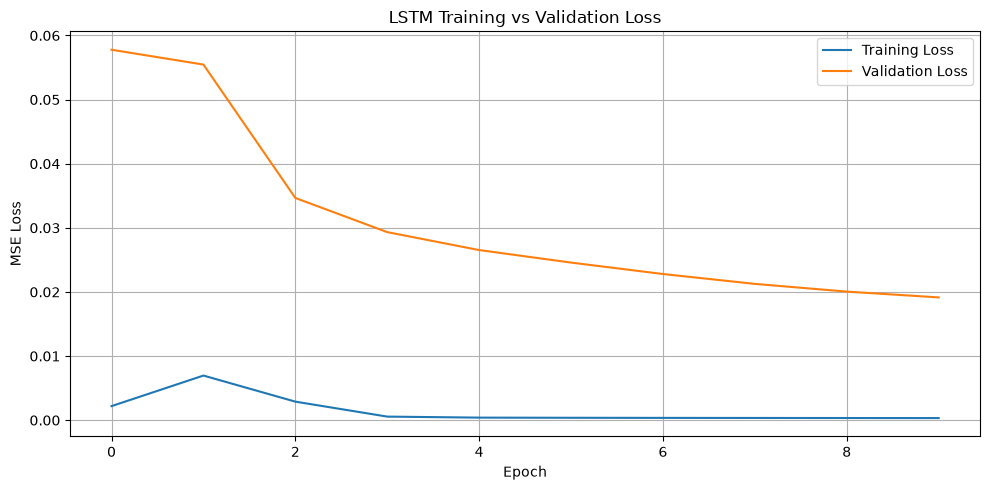

In [65]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title(
    "LSTM Training vs Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


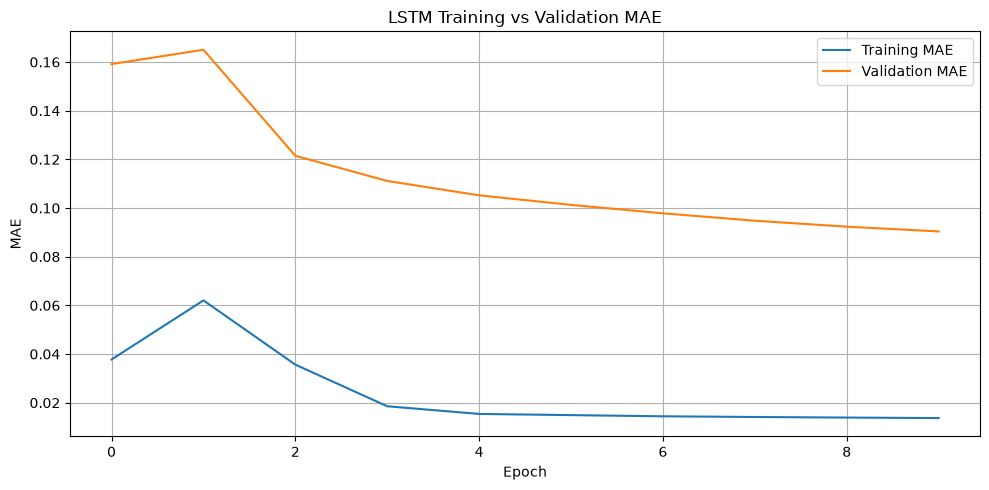

In [66]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(

    history.history["mae"],

    label="Training MAE"

)

plt.plot(

    history.history["val_mae"],

    label="Validation MAE"

)

plt.title(
    "LSTM Training vs Validation MAE"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MAE"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


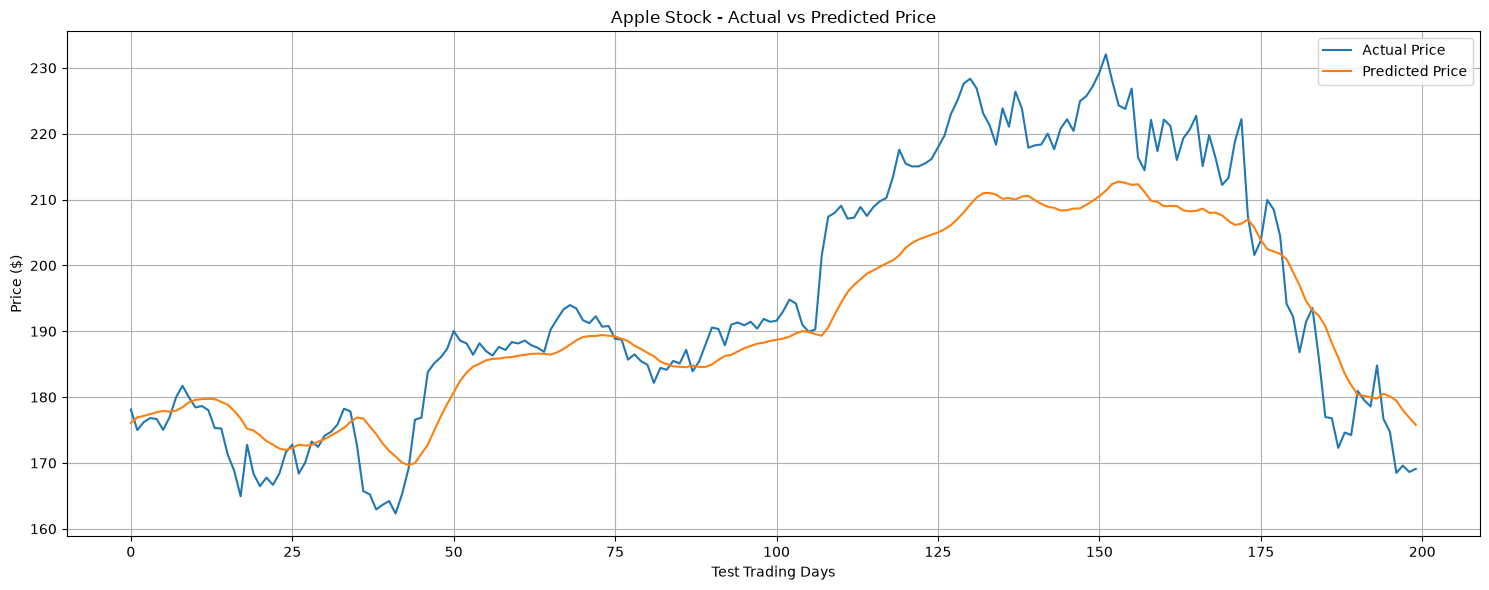

In [67]:
display_count = min(
    200,
    len(actual_prices)
)


plt.figure(
    figsize=(15, 6)
)

plt.plot(

    actual_prices[
        :display_count
    ],

    label="Actual Price"

)

plt.plot(

    predictions_actual[
        :display_count
    ],

    label="Predicted Price"

)

plt.title(
    "Apple Stock - Actual vs Predicted Price"
)

plt.xlabel(
    "Test Trading Days"
)

plt.ylabel(
    "Price ($)"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


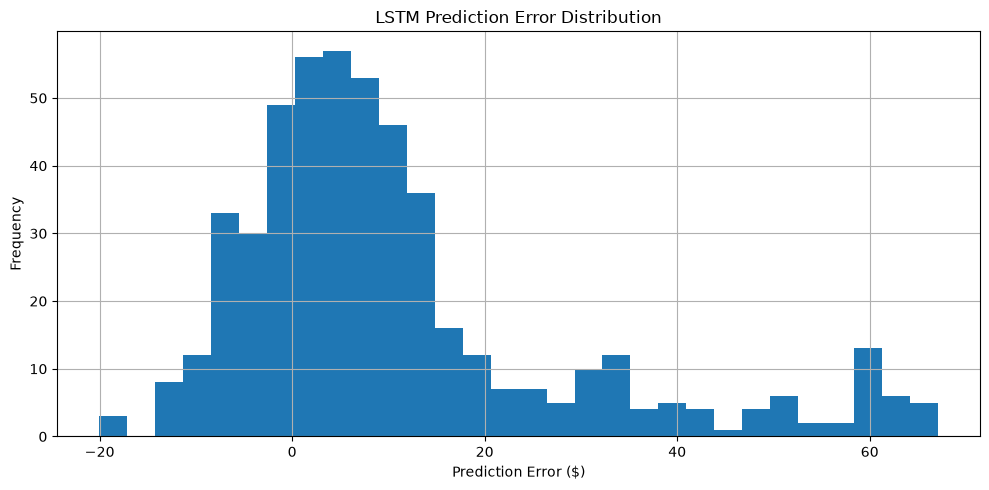

In [68]:
errors = (

    actual_prices.flatten()

    -

    predictions_actual.flatten()

)


plt.figure(
    figsize=(10, 5)
)

plt.hist(

    errors,

    bins=30

)

plt.title(
    "LSTM Prediction Error Distribution"
)

plt.xlabel(
    "Prediction Error ($)"
)

plt.ylabel(
    "Frequency"
)

plt.grid()

plt.tight_layout()

plt.show()


In [69]:
evaluation_summary = pd.DataFrame({

    "Metric": [

        "MAE",

        "MSE",

        "RMSE"

    ],

    "Value": [

        float(mae),

        float(mse),

        float(rmse)

    ]

})


print("\n")
print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)

display(
    evaluation_summary
)




EVALUATION SUMMARY


,Metric,Value
0,MAE,13.506220
1,MSE,427.545685
2,RMSE,20.677178


In [70]:
model_summary = pd.DataFrame({

    "Parameter": [

        "Dataset",

        "Problem",

        "Target",

        "Model",

        "LSTM Units",

        "Dense Units",

        "Sequence Length",

        "Batch Size",

        "Epochs",

        "Optimizer",

        "Loss",

        "MAE",

        "RMSE"

    ],

    "Value": [

        "Apple Historical Quotes",

        "Stock Price Forecasting",

        "Close/Last",

        "Lightweight LSTM",

        32,

        16,

        SEQUENCE_LENGTH,

        BATCH_SIZE,

        10,

        "Adam",

        "MSE",

        round(
            float(mae),
            4
        ),

        round(
            float(rmse),
            4
        )

    ]

})


print("\n")
print("=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

display(
    model_summary
)




MODEL SUMMARY


,Parameter,Value
0,Dataset,Apple Historical Quotes
1,Problem,Stock Price Forecasting
2,Target,Close/Last
3,Model,Lightweight LSTM
4,LSTM Units,32
5,Dense Units,16
6,Sequence Length,30
7,Batch Size,16
8,Epochs,10
9,Optimizer,Adam


In [71]:
print("\n")
print("=" * 70)
print("ML INSIGHTS")
print("=" * 70)

print(
    "1. LSTM can learn temporal patterns from previous prices."
)

print(
    "2. MinMax scaling helps stabilize neural network training."
)

print(
    "3. Chronological splitting prevents future-data leakage."
)

print(
    "4. MAE represents the average absolute prediction error."
)

print(
    "5. RMSE gives greater penalty to large prediction errors."
)

print(
    "6. EarlyStopping helps reduce unnecessary CPU training."
)

print(
    "7. A single lightweight LSTM is suitable for CPU experimentation."
)




ML INSIGHTS
1. LSTM can learn temporal patterns from previous prices.
2. MinMax scaling helps stabilize neural network training.
3. Chronological splitting prevents future-data leakage.
4. MAE represents the average absolute prediction error.
5. RMSE gives greater penalty to large prediction errors.
6. EarlyStopping helps reduce unnecessary CPU training.
7. A single lightweight LSTM is suitable for CPU experimentation.


In [72]:
print("\n")
print("=" * 70)
print("IMPORTANT LIMITATION")
print("=" * 70)

print(
    "This model learns historical price patterns."
)

print(
    "It does NOT guarantee future stock-market returns."
)

print(
    "Stock prices are affected by news, market conditions,"
)

print(
    "economic factors, company fundamentals, and investor sentiment."
)



IMPORTANT LIMITATION
This model learns historical price patterns.
It does NOT guarantee future stock-market returns.
Stock prices are affected by news, market conditions,
economic factors, company fundamentals, and investor sentiment.


In [73]:
print(
    "Best Model Saved As: best_lstm_model.keras"
)

print(
    "Ready for Part-3 Deployment and Future Forecasting."
)

print("=" * 70)


Best Model Saved As: best_lstm_model.keras
Ready for Part-3 Deployment and Future Forecasting.


In [74]:
import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import load_model

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

In [75]:
MODEL_PATH = "best_lstm_model.keras"


if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        f"{MODEL_PATH} not found. "
        "Please run Part-2 first."
    )


loaded_model = load_model(
    MODEL_PATH
)


print("\n")
print("=" * 70)
print("LSTM MODEL LOADED SUCCESSFULLY")
print("=" * 70)

print(
    "Model File :",
    MODEL_PATH
)




LSTM MODEL LOADED SUCCESSFULLY
Model File : best_lstm_model.keras


In [76]:
print("\n")
print("=" * 70)
print("LOADED MODEL SUMMARY")
print("=" * 70)

loaded_model.summary()



LOADED MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,693 (57.40 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,796 (38.27 KB)

In [77]:
test_predictions_scaled = loaded_model.predict(

    X_test,

    verbose=0

)

In [78]:
test_predictions_actual = scaler.inverse_transform(

    test_predictions_scaled

)


test_actual_prices = scaler.inverse_transform(

    y_test.reshape(
        -1,
        1
    )

)

In [79]:
final_mae = mean_absolute_error(

    test_actual_prices,

    test_predictions_actual

)


final_mse = mean_squared_error(

    test_actual_prices,

    test_predictions_actual

)


final_rmse = np.sqrt(
    final_mse
)


print("\n")
print("=" * 70)
print("FINAL TEST PERFORMANCE")
print("=" * 70)

print(
    "MAE  :",
    round(
        float(final_mae),
        4
    )
)

print(
    "MSE  :",
    round(
        float(final_mse),
        4
    )
)

print(
    "RMSE :",
    round(
        float(final_rmse),
        4
    )
)




FINAL TEST PERFORMANCE
MAE  : 13.5062
MSE  : 427.5457
RMSE : 20.6772


In [80]:
test_prediction_df = pd.DataFrame({

    "Actual Price":
        test_actual_prices.flatten(),

    "Predicted Price":
        test_predictions_actual.flatten(),

    "Error":
        (
            test_actual_prices.flatten()
            -
            test_predictions_actual.flatten()
        )

})


print("\n")
print("=" * 70)
print("TEST PREDICTIONS")
print("=" * 70)

display(
    test_prediction_df.head(20)
)



TEST PREDICTIONS


,Actual Price,Predicted Price,Error
0,178.119995,176.052856,2.067139
1,175.000000,176.908676,-1.908676
2,176.210007,177.146606,-0.936600
3,176.820023,177.424942,-0.604919
4,176.669998,177.702698,-1.032700
5,175.029999,177.889328,-2.859329
6,176.940002,177.793655,-0.853653
7,179.979996,177.934814,2.045181
8,181.720001,178.474365,3.245636
9,179.970001,179.199341,0.770660


In [81]:
test_prediction_df.to_csv(

    "LSTM_Test_Predictions.csv",

    index=False

)


print("\n")
print("=" * 70)
print("TEST PREDICTIONS SAVED")
print("=" * 70)

print(
    "File : LSTM_Test_Predictions.csv"
)



TEST PREDICTIONS SAVED
File : LSTM_Test_Predictions.csv


In [82]:
evaluation_df = pd.DataFrame({

    "Metric": [

        "MAE",

        "MSE",

        "RMSE"

    ],

    "Value": [

        float(final_mae),

        float(final_mse),

        float(final_rmse)

    ]

})


evaluation_df.to_csv(

    "LSTM_Evaluation_Metrics.csv",

    index=False

)


print("\n")
print("=" * 70)
print("EVALUATION METRICS SAVED")
print("=" * 70)

display(
    evaluation_df
)




EVALUATION METRICS SAVED


,Metric,Value
0,MAE,13.506220
1,MSE,427.545685
2,RMSE,20.677178


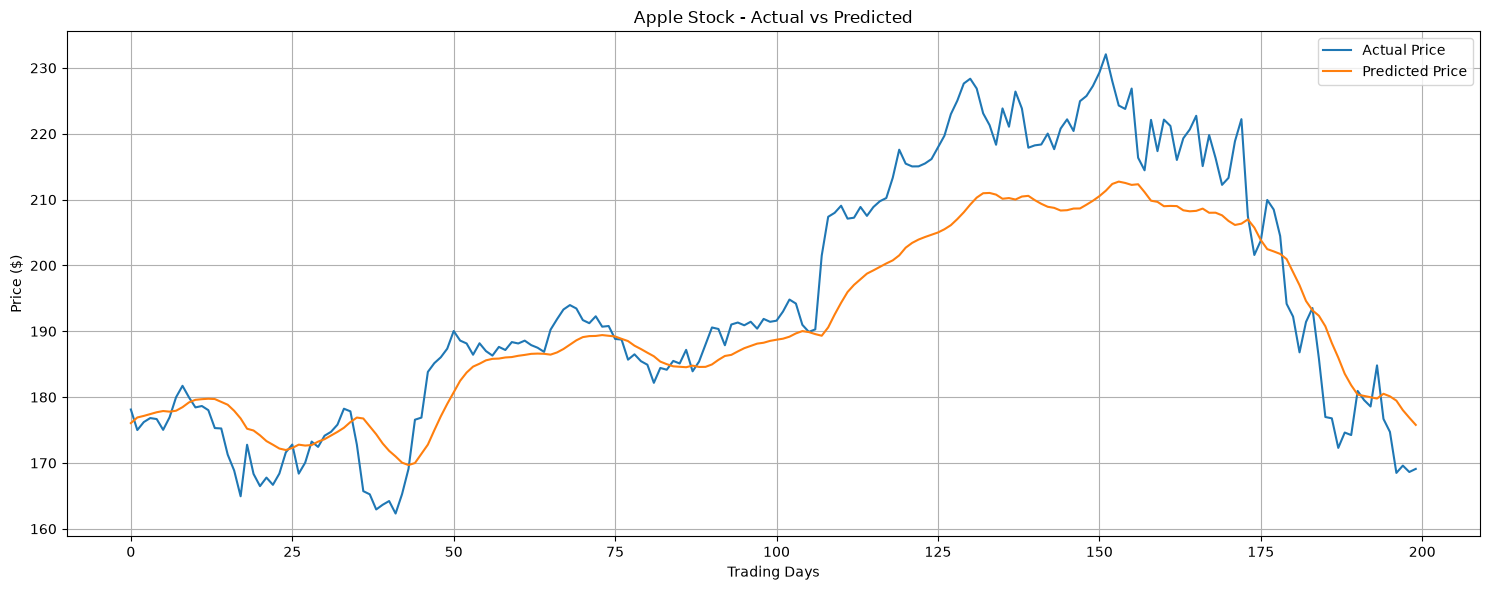

In [83]:
display_count = min(

    200,

    len(test_actual_prices)

)


plt.figure(

    figsize=(15, 6)

)


plt.plot(

    test_actual_prices[
        :display_count
    ],

    label="Actual Price"

)


plt.plot(

    test_predictions_actual[
        :display_count
    ],

    label="Predicted Price"

)


plt.title(

    "Apple Stock - Actual vs Predicted"

)


plt.xlabel(

    "Trading Days"

)


plt.ylabel(

    "Price ($)"

)


plt.legend()

plt.grid()

plt.tight_layout()

plt.show()



In [84]:
last_sequence = close_prices[
    -SEQUENCE_LENGTH:
]
last_sequence_scaled = scaler.transform(

    last_sequence

).astype(

    np.float32

)
last_sequence_scaled = last_sequence_scaled.reshape(

    1,

    SEQUENCE_LENGTH,

    1

)


next_prediction_scaled = loaded_model.predict(

    last_sequence_scaled,

    verbose=0

)


next_prediction = scaler.inverse_transform(

    next_prediction_scaled

)


next_price = float(

    next_prediction[0][0]

)


last_known_price = float(

    close_prices[-1][0]

)


print("\n")
print("=" * 70)
print("NEXT TRADING DAY FORECAST")
print("=" * 70)

print(

    "Last Known Close : $",

    round(
        last_known_price,
        2
    )

)

print(

    "Predicted Next Close : $",

    round(
        next_price,
        2
    )

)




NEXT TRADING DAY FORECAST
Last Known Close : $ 273.36
Predicted Next Close : $ 247.6


In [85]:
predicted_change = (

    next_price

    -

    last_known_price

)


predicted_change_percentage = (

    predicted_change

    /

    last_known_price

) * 100


print("\n")

print(
    "Predicted Change : $",
    round(
        predicted_change,
        2
    )
)


print(
    "Predicted Change % :",
    round(
        predicted_change_percentage,
        2
    ),
    "%"
)




Predicted Change : $ -25.76
Predicted Change % : -9.42 %


In [86]:
predicted_change = (

    next_price

    -

    last_known_price

)


predicted_change_percentage = (

    predicted_change

    /

    last_known_price

) * 100


print("\n")

print(
    "Predicted Change : $",
    round(
        predicted_change,
        2
    )
)


print(
    "Predicted Change % :",
    round(
        predicted_change_percentage,
        2
    ),
    "%"
)




Predicted Change : $ -25.76
Predicted Change % : -9.42 %


In [89]:
FORECAST_DAYS = 5


future_predictions = []


current_sequence = last_sequence_scaled.copy()


for day in range(

    FORECAST_DAYS

):

    prediction_scaled = loaded_model.predict(

        current_sequence,

        verbose=0

    )


    prediction_value = float(

        prediction_scaled[0][0]

    )


    prediction_actual = scaler.inverse_transform(

        prediction_scaled

    )[0][0]


    future_predictions.append(

        float(
            prediction_actual
        )

    )


    # Remove oldest observation
    # and append new prediction.

    new_value = np.array(

        [[[prediction_value]]],

        dtype=np.float32

    )


    current_sequence = np.concatenate(

        [

            current_sequence[:, 1:, :],

            new_value

        ],

        axis=1

    )



In [90]:
last_date = stock_df["Date"].iloc[-1]


future_dates = pd.bdate_range(

    start=last_date + pd.Timedelta(days=1),

    periods=FORECAST_DAYS

)


future_forecast_df = pd.DataFrame({

    "Forecast Date":
        future_dates,

    "Predicted Close":
        future_predictions

})


print("\n")
print("=" * 70)
print("5-DAY FUTURE FORECAST")
print("=" * 70)

display(
    future_forecast_df
)





5-DAY FUTURE FORECAST


,Forecast Date,Predicted Close
0,2020-03-02,247.602722
1,2020-03-03,242.683853
2,2020-03-04,238.086990
3,2020-03-05,233.791824
4,2020-03-06,229.826141


In [91]:
future_forecast_df.to_csv(

    "LSTM_Future_Forecast.csv",

    index=False

)


print("\n")
print("=" * 70)
print("FUTURE FORECAST SAVED")
print("=" * 70)

print(
    "File : LSTM_Future_Forecast.csv"
)




FUTURE FORECAST SAVED
File : LSTM_Future_Forecast.csv


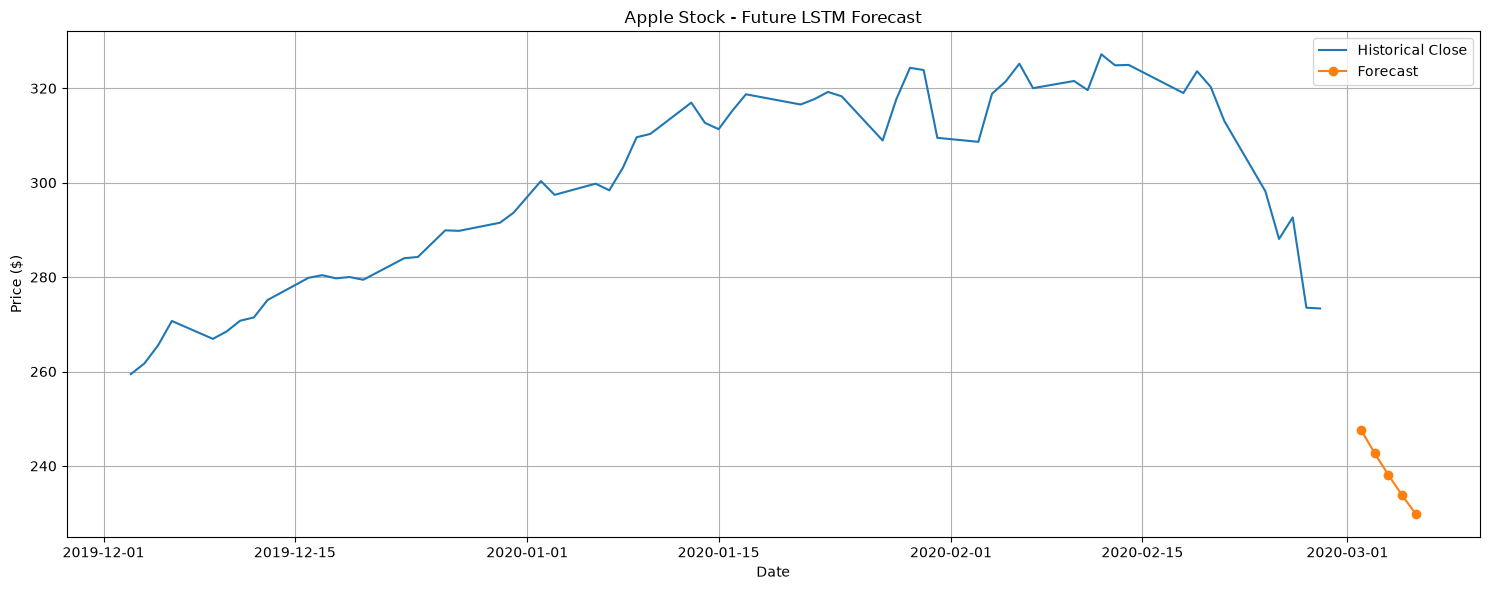

In [92]:
recent_count = min(

    60,

    len(stock_df)

)


recent_dates = stock_df[

    "Date"

].iloc[

    -recent_count:

]


recent_prices = stock_df[

    "Close/Last"

].iloc[

    -recent_count:

]


plt.figure(

    figsize=(15, 6)

)


plt.plot(

    recent_dates,

    recent_prices,

    label="Historical Close"

)


plt.plot(

    future_forecast_df[
        "Forecast Date"
    ],

    future_forecast_df[
        "Predicted Close"
    ],

    marker="o",

    label="Forecast"

)


plt.title(

    "Apple Stock - Future LSTM Forecast"

)


plt.xlabel(

    "Date"

)


plt.ylabel(

    "Price ($)"

)


plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


In [93]:
deployment_summary = pd.DataFrame({

    "Component": [

        "Dataset",

        "Target",

        "Model",

        "Sequence Length",

        "LSTM Units",

        "Batch Size",

        "Epochs",

        "MAE",

        "MSE",

        "RMSE",

        "Next Day Prediction",

        "Forecast Horizon"

    ],

    "Value": [

        "Apple Historical Quotes",

        "Close/Last",

        "Lightweight LSTM",

        SEQUENCE_LENGTH,

        32,

        BATCH_SIZE,

        10,

        round(
            float(final_mae),
            4
        ),

        round(
            float(final_mse),
            4
        ),

        round(
            float(final_rmse),
            4
        ),

        round(
            next_price,
            2
        ),

        f"{FORECAST_DAYS} trading days"

    ]

})


print("\n")
print("=" * 70)
print("DEPLOYMENT SUMMARY")
print("=" * 70)

display(
    deployment_summary
)




DEPLOYMENT SUMMARY


,Component,Value
0,Dataset,Apple Historical Quotes
1,Target,Close/Last
2,Model,Lightweight LSTM
3,Sequence Length,30
4,LSTM Units,32
5,Batch Size,16
6,Epochs,10
7,MAE,13.5062
8,MSE,427.5457
9,RMSE,20.6772


In [94]:
deployment_summary.to_csv(

    "LSTM_Deployment_Summary.csv",

    index=False

)


In [95]:
output_files = pd.DataFrame({

    "Output": [

        "Trained Model",

        "Test Predictions",

        "Evaluation Metrics",

        "Future Forecast",

        "Deployment Summary"

    ],

    "File": [

        "best_lstm_model.keras",

        "LSTM_Test_Predictions.csv",

        "LSTM_Evaluation_Metrics.csv",

        "LSTM_Future_Forecast.csv",

        "LSTM_Deployment_Summary.csv"

    ]

})


print("\n")
print("=" * 70)
print("PROJECT OUTPUT FILES")
print("=" * 70)

display(
    output_files
)




PROJECT OUTPUT FILES


,Output,File
0,Trained Model,best_lstm_model.keras
1,Test Predictions,LSTM_Test_Predictions.csv
2,Evaluation Metrics,LSTM_Evaluation_Metrics.csv
3,Future Forecast,LSTM_Future_Forecast.csv
4,Deployment Summary,LSTM_Deployment_Summary.csv


In [96]:
print("\n")
print("=" * 70)
print("ML INSIGHTS")
print("=" * 70)

print(
    "1. LSTM uses previous trading-day prices to forecast future prices."
)

print(
    "2. The model uses a 30-day historical window."
)

print(
    "3. MinMaxScaler helps keep input values in a neural-network-friendly range."
)

print(
    "4. Chronological splitting prevents future information leakage."
)

print(
    "5. MAE measures average absolute prediction error."
)

print(
    "6. RMSE penalizes larger prediction errors more strongly."
)

print(
    "7. Recursive forecasting becomes increasingly uncertain for longer horizons."
)




ML INSIGHTS
1. LSTM uses previous trading-day prices to forecast future prices.
2. The model uses a 30-day historical window.
3. MinMaxScaler helps keep input values in a neural-network-friendly range.
4. Chronological splitting prevents future information leakage.
5. MAE measures average absolute prediction error.
6. RMSE penalizes larger prediction errors more strongly.
7. Recursive forecasting becomes increasingly uncertain for longer horizons.


In [97]:
print("\n")
print("=" * 70)
print("IMPORTANT LIMITATION")
print("=" * 70)

print(
    "This LSTM is an educational forecasting model."
)

print(
    "It does NOT guarantee future stock prices or investment returns."
)

print(
    "Stock prices are influenced by many external factors,"
)

print(
    "including news, earnings, interest rates, market sentiment,"
)

print(
    "economic conditions, and unexpected events."
)





IMPORTANT LIMITATION
This LSTM is an educational forecasting model.
It does NOT guarantee future stock prices or investment returns.
Stock prices are influenced by many external factors,
including news, earnings, interest rates, market sentiment,
economic conditions, and unexpected events.


In [98]:
print("\n")
print("=" * 70)
print("STOCK PREDICTION USING LSTM")
print("=" * 70)

print(
    "Dataset             : Apple Historical Quotes"
)

print(
    "Target              : Close/Last"
)

print(
    "Model               : Lightweight LSTM"
)

print(
    "Sequence Length     :",
    SEQUENCE_LENGTH
)

print(
    "LSTM Units          : 32"
)

print(
    "Dense Units         : 16"
)

print(
    "Batch Size          :",
    BATCH_SIZE
)

print(
    "Epochs              : 10"
)

print(
    "Optimizer           : Adam"
)

print(
    "Loss                : MSE"
)

print(
    "MAE                 :",
    round(
        float(final_mae),
        4
    )
)

print(
    "RMSE                :",
    round(
        float(final_rmse),
        4
    )
)

print(
    "Next-Day Forecast   : $",
    round(
        next_price,
        2
    )
)

print(
    "Forecast Horizon    :",
    FORECAST_DAYS,
    "trading days"
)

print("=" * 70)




STOCK PREDICTION USING LSTM
Dataset             : Apple Historical Quotes
Target              : Close/Last
Model               : Lightweight LSTM
Sequence Length     : 30
LSTM Units          : 32
Dense Units         : 16
Batch Size          : 16
Epochs              : 10
Optimizer           : Adam
Loss                : MSE
MAE                 : 13.5062
RMSE                : 20.6772
Next-Day Forecast   : $ 247.6
Forecast Horizon    : 5 trading days


In [99]:
print("\n")

print("=" * 70)

print(
    "STOCK PREDICTION USING LSTM"
)

print(
    "PROJECT COMPLETED SUCCESSFULLY!"
)

print("=" * 70)





STOCK PREDICTION USING LSTM
PROJECT COMPLETED SUCCESSFULLY!
